In [2]:
library(tidyverse)
library(ape)
library(TreeSim)
library(phytools)
library(phylolm)
library(TreeTools)
library(tibble)
library(dplyr)
library(readr)
library(data.table)
library(gridExtra)
library(svglite)
library(RColorBrewer)
library(MASS)
library(ROBRT)
library(robust)

### 1. Comparison of FPR

In [114]:
set.seed(19)
yule_tree = sim.bd.taxa(16, 1, 1, 0, 1, complete = FALSE)[[1]]
yule_tree$root.edge=0

PCs = eigen(vcv(yule_tree))$vectors

colnames(PCs) = paste0("PC_",1:ncol(PCs))
PCs = as_tibble(PCs)

num_PC = 8
PC_sets = lapply(seq(from = 2, to = num_PC, by = 2),function(i){paste0("PC_",1:i)})
PC_sets = c("1",PC_sets)

shifts = 10^(seq(log10(1),log10(1e4), len=5))

num_rep = 500
n_edges = length(yule_tree$edge) / 2
n_tips = n_edges / 2 + 1

n_rows = length(shifts) * num_rep * (length(PC_sets) + 1)

In [115]:
p_vals_PC_1 = data.table(
    PCs=numeric(n_rows),
    p.value=numeric(n_rows), 
    shifts=character(n_rows)
)

counter = 1
set.seed(19)

e = yule_tree$edge[11,]
descendants = getDescendants(yule_tree, e[2])
descendants_tips = descendants[descendants <= n_tips]

for (i in 1:length(shifts)) {
    message("Testing for shift size: ", i)
    shift = shifts[i]
    shift = formatC(shift, format = "e", digits = 3)

    for (j in 1:num_rep) {
        BM = fastBM(yule_tree, 1, nsim=2)
        X = BM[,1]
        Y = BM[,2]
            
        X[descendants_tips] = X[descendants_tips] + rnorm(1,0,sd=sqrt(shifts[i]))
        Y[descendants_tips] = Y[descendants_tips] + rnorm(1,0,sd=sqrt(shifts[i]))
            
        all_data = as.data.frame(bind_cols(tibble(X = X, Y = Y),PCs))
        rownames(all_data) = rownames(BM)

        for (l in 1:length(PC_sets)) {
            cur_formula = as.formula(paste(c("Y ~ X", PC_sets[[l]]),collapse=" + "))

            tryCatch({
                cur_lm = phylolm(cur_formula,data=all_data,phy=yule_tree)
                cur_p = summary(cur_lm)$coefficients["X","p.value"]
                    
                p_vals_PC_1[counter, `:=`("PCs" = 2 * (l - 1), "p.value" = cur_p, "shifts" = shift)]
            }, error = function(e) {
                p_vals_PC_1[counter, `:=`("PCs" = 2 * (l - 1), "p.value" = NA, "shifts" = shift)]
            })

            counter = counter + 1
        }

        pic_X = pic(X, yule_tree)
        pic_Y = pic(Y, yule_tree)
            
        all_data = as.data.frame(tibble(pic_X = pic_X, pic_Y = pic_Y))

        cur_rlm = lmRob(pic_Y ~ pic_X - 1, data = all_data, 
                        control = lmRob.control(mxr = 1e8))
        cur_p = summary(cur_rlm)$coefficients["pic_X", "Pr(>|t|)"]
        p_vals_PC_1[counter, `:=`("PCs" = -1, "p.value" = cur_p, "shifts" = shift)]

        counter = counter + 1 
    }
}

Testing for shift size: 1

Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test

In [116]:
p_vals_PC_1_summary = p_vals_PC_1 %>%
  mutate(method = case_when(
    PCs == -1 ~ "PIC + robust regression",
    PCs == 0 ~ "PGLS",
    PCs == 2 ~ "PGLS + 2 eigenvectors",
    PCs == 4 ~ "PGLS + 4 eigenvectors", 
    PCs == 6 ~ "PGLS + 6 eigenvectors", 
    PCs == 8 ~ "PGLS + 8 eigenvectors" 
  )) %>% 
  group_by(method, shifts) %>%
  summarise(FPR = mean(p.value<0.05), n = n(), .groups = "drop")
p_vals_PC_1_summary$sd.shift = sqrt(as.numeric(p_vals_PC_1_summary$shifts))

p_vals_PC_1_summary = as.data.table(p_vals_PC_1_summary) 
p_vals_PC_1_summary$shifts = factor(p_vals_PC_1_summary$shifts)
p_vals_PC_1_summary$method = factor(p_vals_PC_1_summary$method)

In [117]:
plot_1 <- p_vals_PC_1_summary %>% ggplot(aes(x = log10(sd.shift), y = FPR)) +
    geom_line(aes(color = method), linewidth=2) +
    geom_hline(yintercept= 0.05,lty=2) +
    ylab("Fraction of significant tests") + 
    ylim(0, 1) + 
    xlab("log(sd(shift))")+
    theme_classic(base_size=20) +
    theme(axis.title.x = element_text(size = 36), axis.title.y = element_text(size = 36), 
          axis.text.x = element_text(size = 24), axis.text.y = element_text(size = 24),
          legend.position=c(.3,.85),legend.spacing.y = unit(1,"pt"), 
          legend.key.width = unit(1.5, "cm"), 
          legend.title = element_text(size = 24), legend.text = element_text(size = 24)) + 
    scale_color_manual(values=c("#332288","#88CCEE","#44AA99",
                                "#117733","#999933","#CC6677"), 
                      breaks = c("PGLS", "PGLS + 2 eigenvectors", 
                                 "PGLS + 4 eigenvectors", "PGLS + 6 eigenvectors", 
                                 "PGLS + 8 eigenvectors", "PIC + robust regression")) 

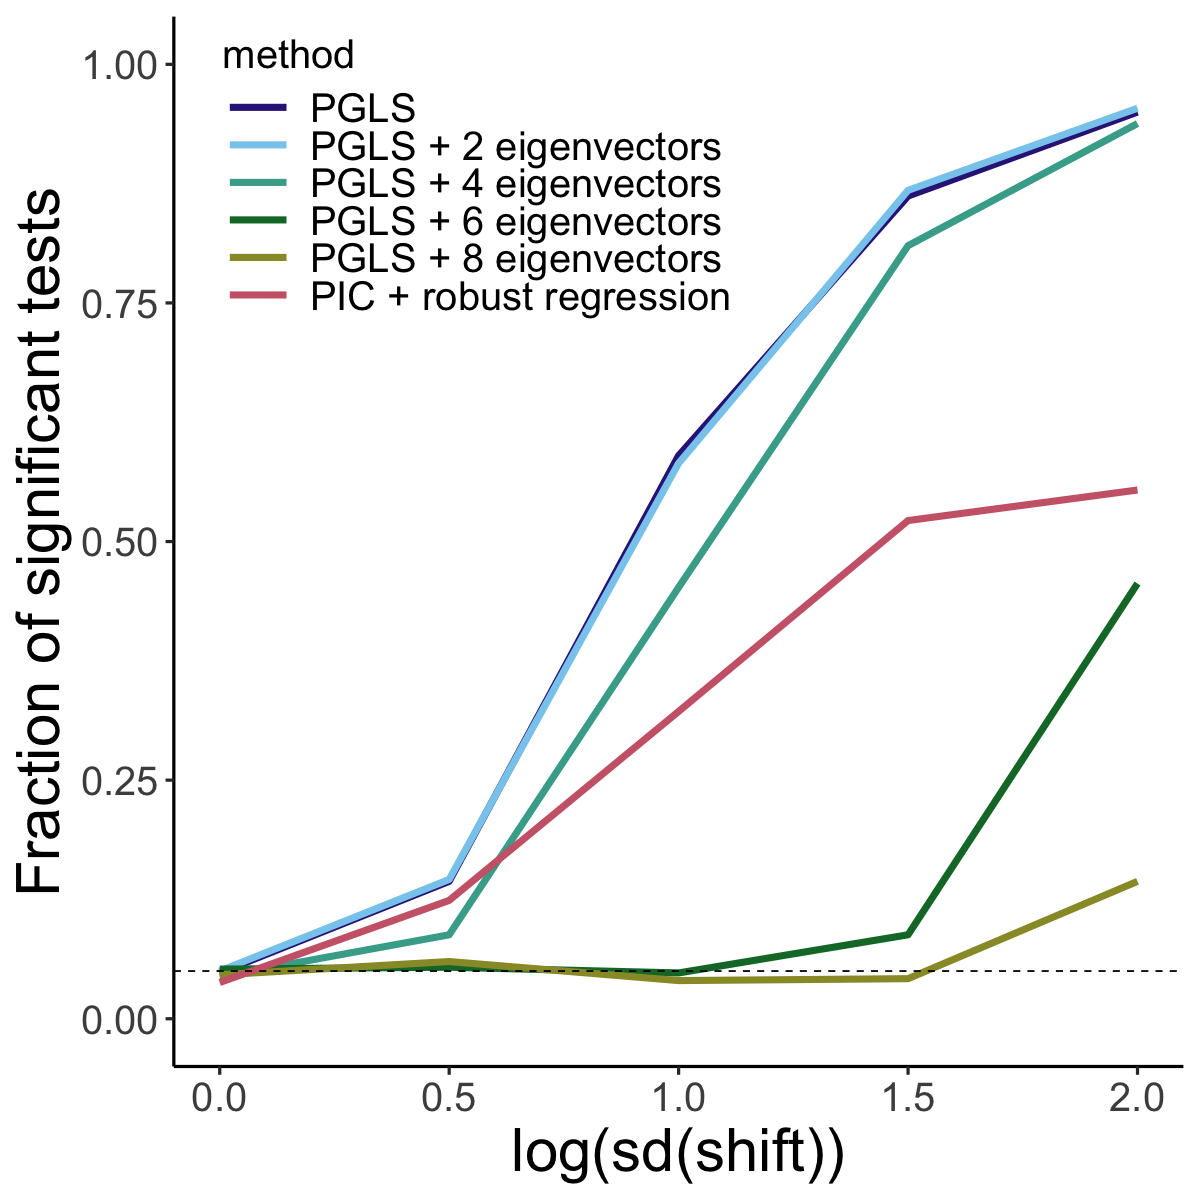

In [118]:
options(repr.plot.width = 10, repr.plot.height = 10)
plot_1

In [119]:
p_vals_PC_2 = data.table(
    PCs=numeric(n_rows),
    p.value=numeric(n_rows),  
    shifts=character(n_rows)
)

counter = 1
set.seed(19)

cand_edges = c(1, 2, 23, 25)
n_cand_edges = length(cand_edges)

for (i in 1:length(shifts)) {
    message("Testing for shift size: ", i)
    shift = shifts[i]
    shift = formatC(shift, format = "e", digits = 3)

    descendants_tips_list <- vector("list", n_cand_edges)
    for (j in 1:n_cand_edges) {
        id_cand = cand_edges[j]
        e_cand = yule_tree$edge[id_cand,]
        descendants_cand = getDescendants(yule_tree, e_cand[2])
        descendants_tips_list[[j]] = descendants_cand[descendants_cand <= n_tips]
    }

    for (m in 1:num_rep) {
        BM = fastBM(yule_tree, 1, nsim=2)
        X = BM[,1]
        Y = BM[,2]
        for (j in 1:n_cand_edges) {
            descendants_tips = descendants_tips_list[[j]]
            X[descendants_tips] = X[descendants_tips] + rnorm(1,0,sd=sqrt(shifts[i]))
            Y[descendants_tips] = Y[descendants_tips] + rnorm(1,0,sd=sqrt(shifts[i]))
        }
            
        all_data = as.data.frame(bind_cols(tibble(X = X, Y = Y),PCs))
        rownames(all_data) = rownames(BM)

        for (l in 1:length(PC_sets)) {
            cur_formula = as.formula(paste(c("Y ~ X", PC_sets[[l]]),collapse=" + "))
            tryCatch({
                    cur_lm = phylolm(cur_formula,data=all_data,phy=yule_tree)
                    cur_p = summary(cur_lm)$coefficients["X","p.value"]                    
                    p_vals_PC_2[counter, `:=`("PCs" = 2 * (l - 1), "p.value" = cur_p,
                                              "shifts" = shift)]
            }, error = function(e) {
                    p_vals_PC_2[counter, `:=`("PCs" = 2 * (l - 1), "p.value" = NA,
                                              "shifts" = shift)]
            })
            counter = counter + 1
        }

        pic_X = pic(X, yule_tree)
        pic_Y = pic(Y, yule_tree)
            
        all_data = as.data.frame(tibble(pic_X = pic_X, pic_Y = pic_Y))

        cur_rlm = lmRob(pic_Y ~ pic_X - 1, data = all_data, 
                        control = lmRob.control(mxr = 1e8))
        cur_p = summary(cur_rlm)$coefficients["pic_X", "Pr(>|t|)"]
        p_vals_PC_2[counter, `:=`("PCs" = -1, "p.value" = cur_p, "shifts" = shift)]

        counter = counter + 1 
    }  
}

Testing for shift size: 1

Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test

In [120]:
p_vals_PC_2_summary = p_vals_PC_2 %>%
  mutate(method = case_when(
    PCs == -1 ~ "PIC + robust regression",
    PCs == 0 ~ "PGLS",
    PCs == 2 ~ "PGLS + 2 eigenvectors",
    PCs == 4 ~ "PGLS + 4 eigenvectors", 
    PCs == 6 ~ "PGLS + 6 eigenvectors", 
    PCs == 8 ~ "PGLS + 8 eigenvectors" 
  )) %>% 
  group_by(method, shifts) %>%
  summarise(FPR = mean(p.value<0.05), n = n(), .groups = "drop")
p_vals_PC_2_summary$sd.shift = sqrt(as.numeric(p_vals_PC_2_summary$shifts))

p_vals_PC_2_summary = as.data.table(p_vals_PC_2_summary) 
p_vals_PC_2_summary$shifts = factor(p_vals_PC_2_summary$shifts)
p_vals_PC_2_summary$method = factor(p_vals_PC_2_summary$method)

In [121]:
plot_2 <- p_vals_PC_2_summary %>% ggplot(aes(x = log10(sd.shift), y = FPR)) +
    geom_line(aes(color = method), linewidth=2) +
    geom_hline(yintercept= 0.05,lty=2) +
    ylab("Fraction of significant tests") + 
    ylim(0, 1) + 
    xlab("log(sd(shift))")+
    theme_classic(base_size=20) +
    theme(axis.title.x = element_text(size = 36), axis.title.y = element_text(size = 36), 
          axis.text.x = element_text(size = 24), axis.text.y = element_text(size = 24),
          legend.position=c(.3,.85),legend.spacing.y = unit(1,"pt"), 
          legend.key.width = unit(1.5, "cm"), 
          legend.title = element_text(size = 24), legend.text = element_text(size = 24)) +  
    scale_color_manual(values=c("#332288","#88CCEE","#44AA99",
                                "#117733","#999933","#CC6677"), 
                      breaks = c("PGLS", "PGLS + 2 eigenvectors", 
                                 "PGLS + 4 eigenvectors", "PGLS + 6 eigenvectors", 
                                 "PGLS + 8 eigenvectors", "PIC + robust regression")) 

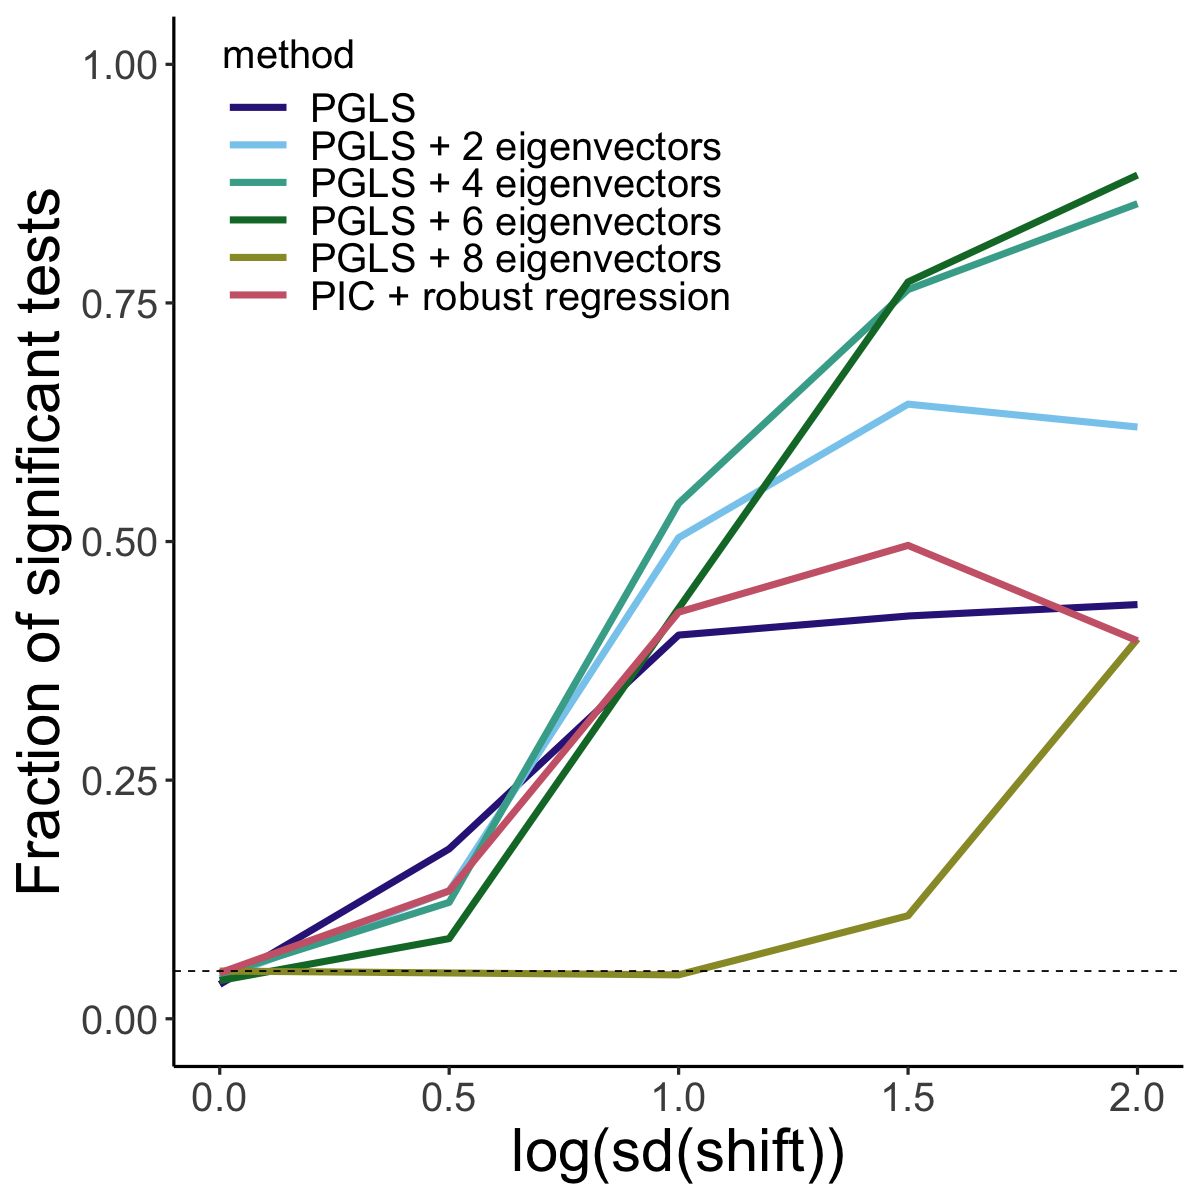

In [122]:
options(repr.plot.width = 10, repr.plot.height = 10)
plot_2

In [123]:
p_vals_PC_3 = data.table(
    PCs=numeric(n_rows),
    p.value=numeric(n_rows),  
    shifts=character(n_rows)
)

counter = 1
set.seed(19)

cand_edges = c(1, 2, 11, 15, 17, 23, 25, 26)
n_cand_edges = length(cand_edges)

for (i in 1:length(shifts)) {
    message("Testing for shift size: ", i)
    shift = shifts[i]
    shift = formatC(shift, format = "e", digits = 3)

    descendants_tips_list <- vector("list", n_cand_edges)
    for (j in 1:n_cand_edges) {
        id_cand = cand_edges[j]
        e_cand = yule_tree$edge[id_cand,]
        descendants_cand = getDescendants(yule_tree, e_cand[2])
        descendants_tips_list[[j]] = descendants_cand[descendants_cand <= n_tips]
    }

    for (m in 1:num_rep) {
        BM = fastBM(yule_tree, 1, nsim=2)
        X = BM[,1]
        Y = BM[,2]
        for (j in 1:n_cand_edges) {
            descendants_tips = descendants_tips_list[[j]]
            X[descendants_tips] = X[descendants_tips] + rnorm(1,0,sd=sqrt(shifts[i]))
            Y[descendants_tips] = Y[descendants_tips] + rnorm(1,0,sd=sqrt(shifts[i]))
        }
            
        all_data = as.data.frame(bind_cols(tibble(X = X, Y = Y),PCs))
        rownames(all_data) = rownames(BM)

        for (l in 1:length(PC_sets)) {
            cur_formula = as.formula(paste(c("Y ~ X", PC_sets[[l]]),collapse=" + "))
            tryCatch({
                    cur_lm = phylolm(cur_formula,data=all_data,phy=yule_tree)
                    cur_p = summary(cur_lm)$coefficients["X","p.value"]                    
                    p_vals_PC_3[counter, `:=`("PCs" = 2 * (l - 1), "p.value" = cur_p,
                                              "shifts" = shift)]
            }, error = function(e) {
                    p_vals_PC_3[counter, `:=`("PCs" = 2 * (l - 1), "p.value" = NA,
                                              "shifts" = shift)]
            })
            counter = counter + 1
        }

        pic_X = pic(X, yule_tree)
        pic_Y = pic(Y, yule_tree)
            
        all_data = as.data.frame(tibble(pic_X = pic_X, pic_Y = pic_Y))

        cur_rlm = lmRob(pic_Y ~ pic_X - 1, data = all_data, 
                        control = lmRob.control(mxr = 1e8))
        cur_p = summary(cur_rlm)$coefficients["pic_X", "Pr(>|t|)"]
        p_vals_PC_3[counter, `:=`("PCs" = -1, "p.value" = cur_p, "shifts" = shift)]

        counter = counter + 1 
    }  
}

Testing for shift size: 1

Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test

In [124]:
p_vals_PC_3_summary = p_vals_PC_3 %>%
  mutate(method = case_when(
    PCs == -1 ~ "PIC + robust regression",
    PCs == 0 ~ "PGLS",
    PCs == 2 ~ "PGLS + 2 eigenvectors",
    PCs == 4 ~ "PGLS + 4 eigenvectors", 
    PCs == 6 ~ "PGLS + 6 eigenvectors", 
    PCs == 8 ~ "PGLS + 8 eigenvectors" 
  )) %>% 
  group_by(method, shifts) %>%
  summarise(FPR = mean(p.value<0.05), n = n(), .groups = "drop")
p_vals_PC_3_summary$sd.shift = sqrt(as.numeric(p_vals_PC_3_summary$shifts))

p_vals_PC_3_summary = as.data.table(p_vals_PC_3_summary) 
p_vals_PC_3_summary$shifts = factor(p_vals_PC_3_summary$shifts)
p_vals_PC_3_summary$method = factor(p_vals_PC_3_summary$method)

In [125]:
plot_3 <- p_vals_PC_3_summary %>% ggplot(aes(x = log10(sd.shift), y = FPR)) +
    geom_line(aes(color = method), linewidth=2) +
    geom_hline(yintercept= 0.05,lty=2) +
    ylab("Fraction of significant tests") + 
    ylim(0, 1) + 
    xlab("log(sd(shift))")+
    theme_classic(base_size=20) +
    theme(axis.title.x = element_text(size = 36), axis.title.y = element_text(size = 36), 
          axis.text.x = element_text(size = 24), axis.text.y = element_text(size = 24),
          legend.position=c(.3,.85),legend.spacing.y = unit(1,"pt"), 
          legend.key.width = unit(1.5, "cm"), 
          legend.title = element_text(size = 24), legend.text = element_text(size = 24)) +  
    scale_color_manual(values=c("#332288","#88CCEE","#44AA99",
                                "#117733","#999933","#CC6677"), 
                      breaks = c("PGLS", "PGLS + 2 eigenvectors", 
                                 "PGLS + 4 eigenvectors", "PGLS + 6 eigenvectors", 
                                 "PGLS + 8 eigenvectors", "PIC + robust regression")) 

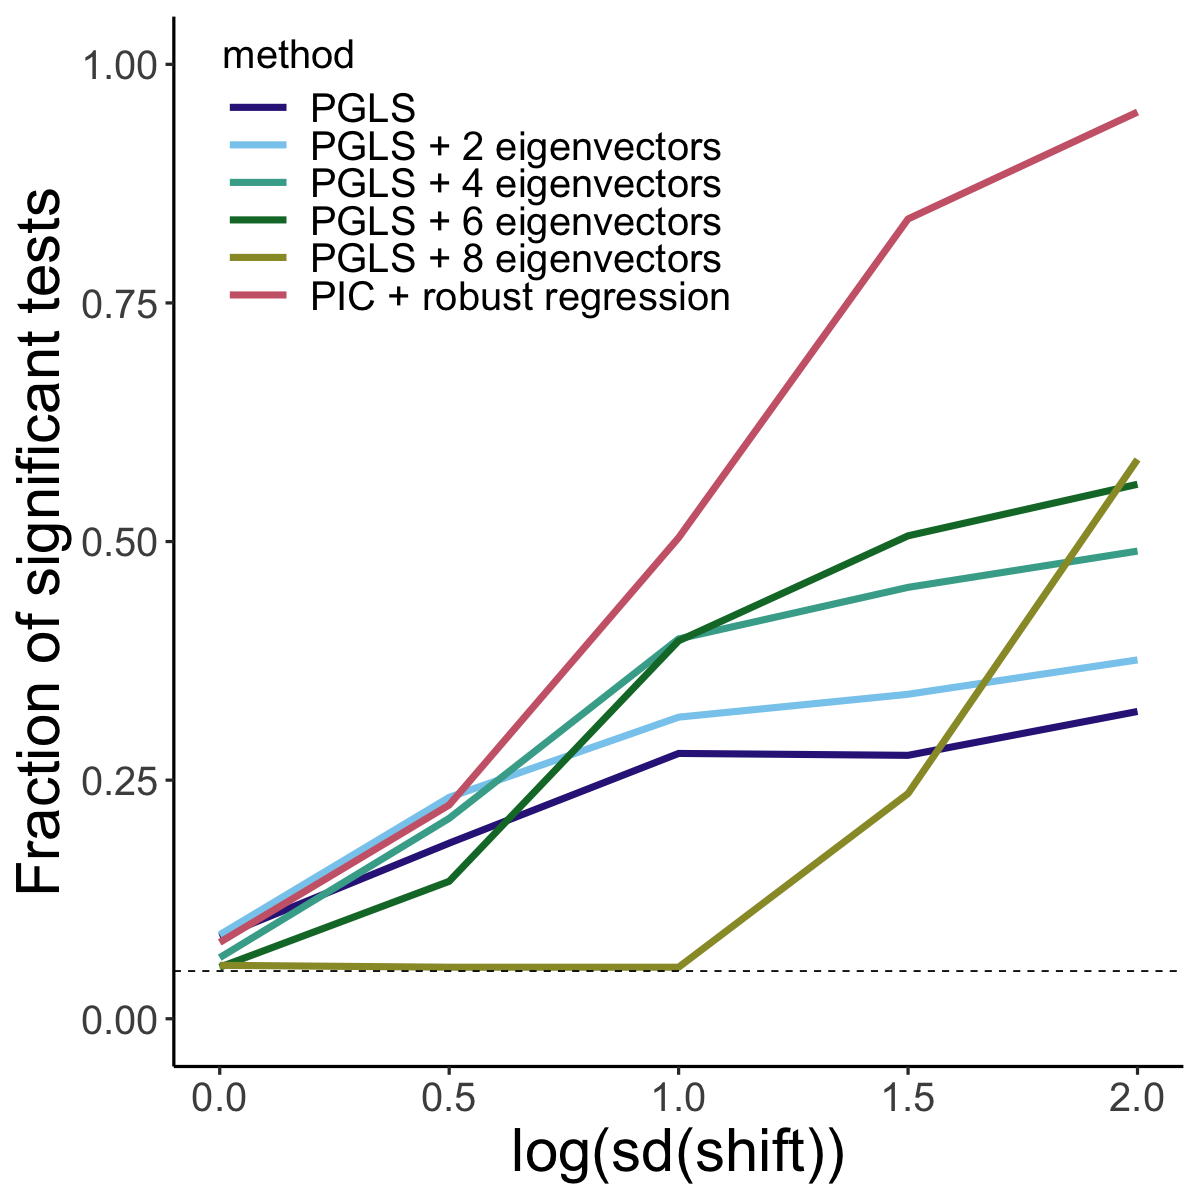

In [126]:
options(repr.plot.width = 10, repr.plot.height = 10)
plot_3

### 2. Comparison of Power

In [128]:
set.seed(19)
yule_tree = sim.bd.taxa(32, 1, 1, 0, 1, complete = FALSE)[[1]]
yule_tree$root.edge=0

PCs = eigen(vcv(yule_tree))$vectors

colnames(PCs) = paste0("PC_",1:ncol(PCs))
PCs = as_tibble(PCs)

num_PC = 16
PC_sets = lapply(seq(from = 4, to = num_PC, by = 4),function(i){paste0("PC_",1:i)})
PC_sets = c("1",PC_sets)

num_rep = 500
n_edges = length(yule_tree$edge) / 2
n_tips = n_edges / 2 + 1

betas = 2 ** c(-4:1)
n_beta = length(betas)

n_rows = n_beta * num_rep * (length(PC_sets) + 1)

In [129]:
p_vals_PC_4 = data.table(
    PCs=numeric(n_rows),
    p.value=numeric(n_rows), 
    beta.size = numeric(n_rows)
)

counter = 1
set.seed(19)

for (j in 1:num_rep) {
    if (j %% 10 == 0) {message("repeat: ", j)}
        
    for (k in 1:n_beta) {
        beta = betas[k]

        BM = fastBM(yule_tree,1,nsim=2)
        X = BM[,1]
        Y = X * beta + BM[,2]
    
        all_data = as.data.frame(bind_cols(tibble(X = X, Y = Y),PCs))
        rownames(all_data) = rownames(BM)

        for (l in 1:length(PC_sets)) {
            cur_formula = as.formula(paste(c("Y ~ X", PC_sets[[l]]),collapse=" + "))
                
            tryCatch({
                cur_lm = phylolm(cur_formula,data=all_data,phy=yule_tree)
                cur_p = summary(cur_lm)$coefficients["X","p.value"]
                          
                p_vals_PC_4[counter, `:=`("PCs" = 4 * (l - 1), "p.value" = cur_p,  
                                          "beta.size" = beta)]
            }, error = function(e) { 
                    
                p_vals_PC_4[counter, `:=`("PCs" = 4 * (l - 1), "p.value" = NA, 
                                          "beta.size" = beta)]
            })

            counter = counter + 1
        }

        pic_X = pic(X, yule_tree)
        pic_Y = pic(Y, yule_tree)
            
        all_data = as.data.frame(tibble(pic_X = pic_X, pic_Y = pic_Y))

        cur_rlm = lmRob(pic_Y ~ pic_X - 1, data = all_data, 
                        control = lmRob.control(mxr = 1e8))
        cur_p = summary(cur_rlm)$coefficients["pic_X", "Pr(>|t|)"]
        p_vals_PC_4[counter, `:=`("PCs" = -1, "p.value" = cur_p, "beta.size" = beta)]

        counter = counter + 1
    } 
}

Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
repeat: 10

Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
repeat: 20

Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
repeat: 30

Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
repeat: 40

re

In [131]:
p_vals_PC_4_summary = p_vals_PC_4 %>%
  mutate(method = case_when(
    PCs == -1 ~ "PIC + robust regression",
    PCs == 0 ~ "PGLS",
    PCs == 4 ~ "PGLS + 4 eigenvectors",
    PCs == 8 ~ "PGLS + 8 eigenvectors", 
    PCs == 12 ~ "PGLS + 12 eigenvectors", 
    PCs == 16 ~ "PGLS + 16 eigenvectors" 
  )) %>% 
  group_by(method, beta.size) %>%
  summarise(FPR = mean(p.value<0.05), n = n(), .groups = "drop")

p_vals_PC_4_summary = as.data.table(p_vals_PC_4_summary) 
p_vals_PC_4_summary$method = factor(p_vals_PC_4_summary$method)

In [134]:
plot_4 <- p_vals_PC_4_summary %>% 
    ggplot(aes(beta.size, FPR)) +
    geom_line(aes(color = method), linewidth=2) +
    theme_classic(base_size=20) +
    xlab(expression(beta)) +
    ylab("Fraction of significant tests") + 
    scale_x_continuous(trans = 'log2', breaks = 2^(-4:1), 
                       labels = function(x) parse(text = paste0("2^", log2(x)))) +
    ylim(0, 1) +
    theme(axis.title.x = element_text(size = 36), axis.title.y = element_text(size = 36), 
          axis.text.x = element_text(size = 24), axis.text.y = element_text(size = 24),
          legend.position=c(.3,.85),legend.spacing.y = unit(1,"pt"), 
          legend.key.width = unit(1.5, "cm"), 
          legend.title = element_text(size = 24), legend.text = element_text(size = 24)) +
    scale_color_manual(values=c("#332288","#88CCEE","#44AA99",
                                "#117733","#999933","#CC6677"), 
                      breaks = c("PGLS", "PGLS + 4 eigenvectors", 
                                 "PGLS + 8 eigenvectors", "PGLS + 12 eigenvectors", 
                                 "PGLS + 16 eigenvectors", "PIC + robust regression")) 

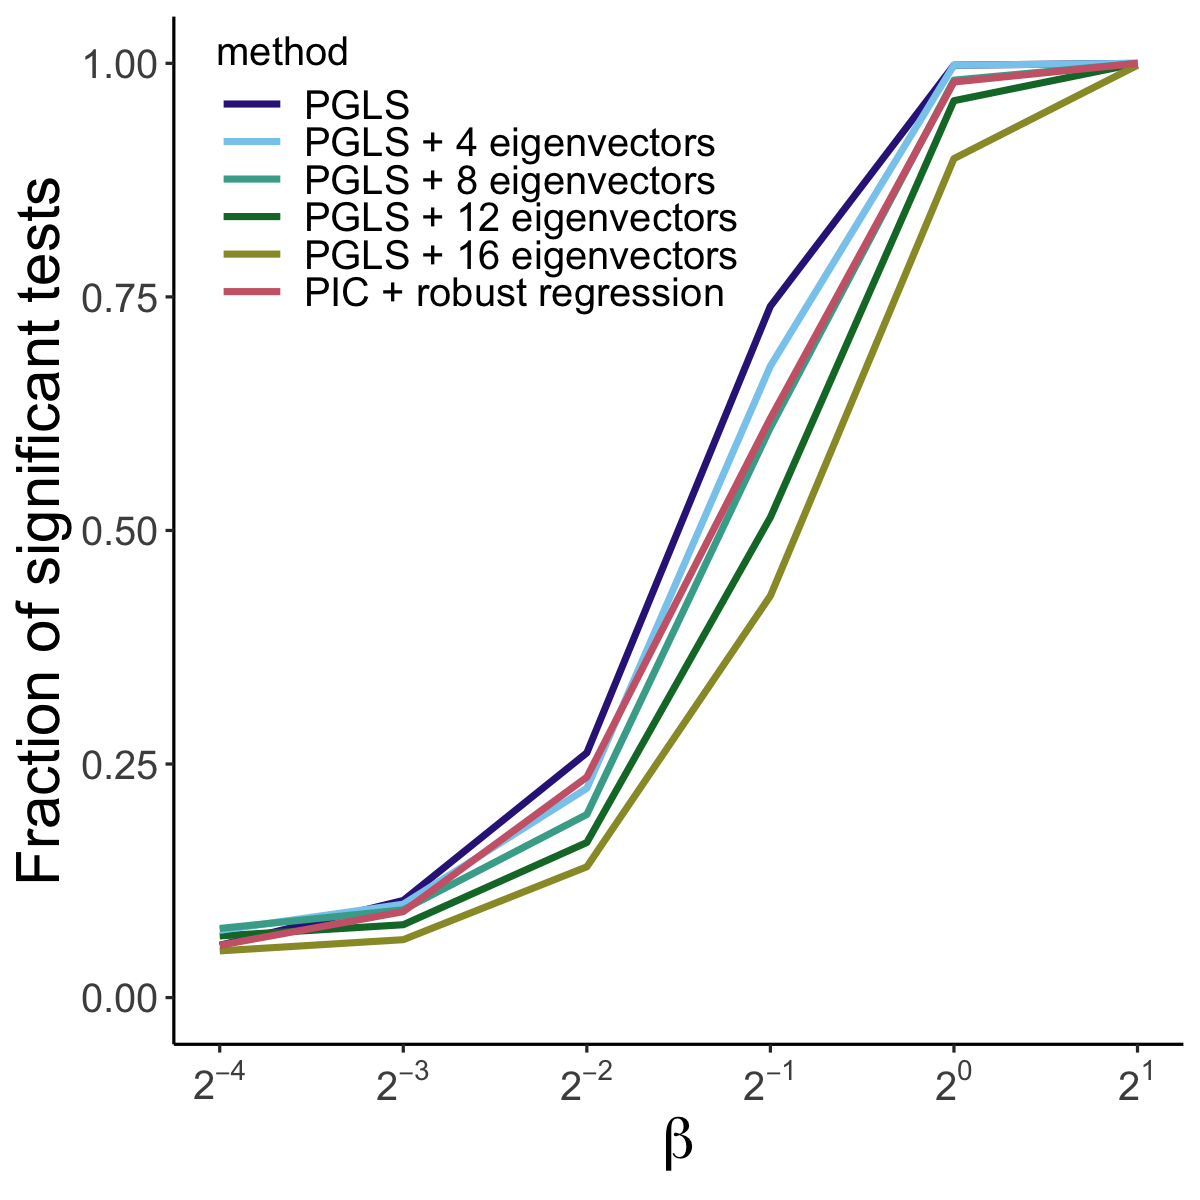

In [135]:
options(repr.plot.width = 10, repr.plot.height = 10)
plot_4

In [143]:
set.seed(19)
yule_tree = sim.bd.taxa(64, 1, 1, 0, 1, complete = FALSE)[[1]]
yule_tree$root.edge=0

PCs = eigen(vcv(yule_tree))$vectors

colnames(PCs) = paste0("PC_",1:ncol(PCs))
PCs = as_tibble(PCs)

num_PC = 32
PC_sets = lapply(seq(from = 8, to = num_PC, by = 8),function(i){paste0("PC_",1:i)})
PC_sets = c("1",PC_sets)

n_edges = length(yule_tree$edge) / 2
n_tips = n_edges / 2 + 1

n_rows = n_beta * num_rep * (length(PC_sets) + 1)

In [144]:
p_vals_PC_5 = data.table(
    PCs=numeric(n_rows),
    p.value=numeric(n_rows), 
    beta.size = numeric(n_rows)
)

counter = 1
set.seed(19)

for (j in 1:num_rep) {
    if (j %% 10 == 0) {message("repeat: ", j)}
        
    for (k in 1:n_beta) {
        beta = betas[k]

        BM = fastBM(yule_tree,1,nsim=2)
        X = BM[,1]
        Y = X * beta + BM[,2]
    
        all_data = as.data.frame(bind_cols(tibble(X = X, Y = Y),PCs))
        rownames(all_data) = rownames(BM)

        for (l in 1:length(PC_sets)) {
            cur_formula = as.formula(paste(c("Y ~ X", PC_sets[[l]]),collapse=" + "))
                
            tryCatch({
                cur_lm = phylolm(cur_formula,data=all_data,phy=yule_tree)
                cur_p = summary(cur_lm)$coefficients["X","p.value"]
                          
                p_vals_PC_5[counter, `:=`("PCs" = 8 * (l - 1), "p.value" = cur_p,  
                                          "beta.size" = beta)]
            }, error = function(e) { 
                    
                p_vals_PC_5[counter, `:=`("PCs" = 8 * (l - 1), "p.value" = NA, 
                                          "beta.size" = beta)]
            })

            counter = counter + 1
        }

        pic_X = pic(X, yule_tree)
        pic_Y = pic(Y, yule_tree)
            
        all_data = as.data.frame(tibble(pic_X = pic_X, pic_Y = pic_Y))

        cur_rlm = lmRob(pic_Y ~ pic_X - 1, data = all_data, 
                        control = lmRob.control(mxr = 1e8))
        cur_p = summary(cur_rlm)$coefficients["pic_X", "Pr(>|t|)"]
        p_vals_PC_5[counter, `:=`("PCs" = -1, "p.value" = cur_p, "beta.size" = beta)]

        counter = counter + 1
    } 
}

Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
repeat: 10

repeat: 20

repeat: 30

repeat: 40

repeat: 50

Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
repeat: 60

Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
repeat: 70

repeat: 80

Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
repeat: 90

Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
repeat: 100

Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
repeat: 110

repeat: 120

Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
repeat: 130

repeat: 140

Warning message in test.lmRob(object):
“Denominator smaller than tl

In [145]:
p_vals_PC_5_summary = p_vals_PC_5 %>%
  mutate(method = case_when(
    PCs == -1 ~ "PIC + robust regression",
    PCs == 0 ~ "PGLS",
    PCs == 8 ~ "PGLS + 8 eigenvectors",
    PCs == 16 ~ "PGLS + 16 eigenvectors", 
    PCs == 24 ~ "PGLS + 24 eigenvectors", 
    PCs == 32 ~ "PGLS + 32 eigenvectors" 
  )) %>% 
  group_by(method, beta.size) %>%
  summarise(FPR = mean(p.value<0.05), n = n(), .groups = "drop")

p_vals_PC_5_summary = as.data.table(p_vals_PC_5_summary) 
p_vals_PC_5_summary$method = factor(p_vals_PC_5_summary$method)

In [152]:
plot_5 <- p_vals_PC_5_summary %>% 
    ggplot(aes(beta.size, FPR)) +
    geom_line(aes(color = method), linewidth=2) +
    theme_classic(base_size=20) +
    xlab(expression(beta)) +
    ylab("Fraction of significant tests") + 
    scale_x_continuous(trans = 'log2', breaks = 2^(-4:1), 
                       labels = function(x) parse(text = paste0("2^", log2(x)))) +
    ylim(0, 1) +
    theme(axis.title.x = element_text(size = 36), axis.title.y = element_text(size = 36), 
          axis.text.x = element_text(size = 24), axis.text.y = element_text(size = 24),
          legend.position=c(.72,.2),legend.spacing.y = unit(1,"pt"), 
          legend.key.width = unit(1.5, "cm"), 
          legend.title = element_text(size = 24), legend.text = element_text(size = 24)) +
    scale_color_manual(values=c("#332288","#88CCEE","#44AA99",
                                "#117733","#999933","#CC6677"), 
                      breaks = c("PGLS", "PGLS + 8 eigenvectors", 
                                 "PGLS + 16 eigenvectors", "PGLS + 24 eigenvectors", 
                                 "PGLS + 32 eigenvectors", "PIC + robust regression")) 

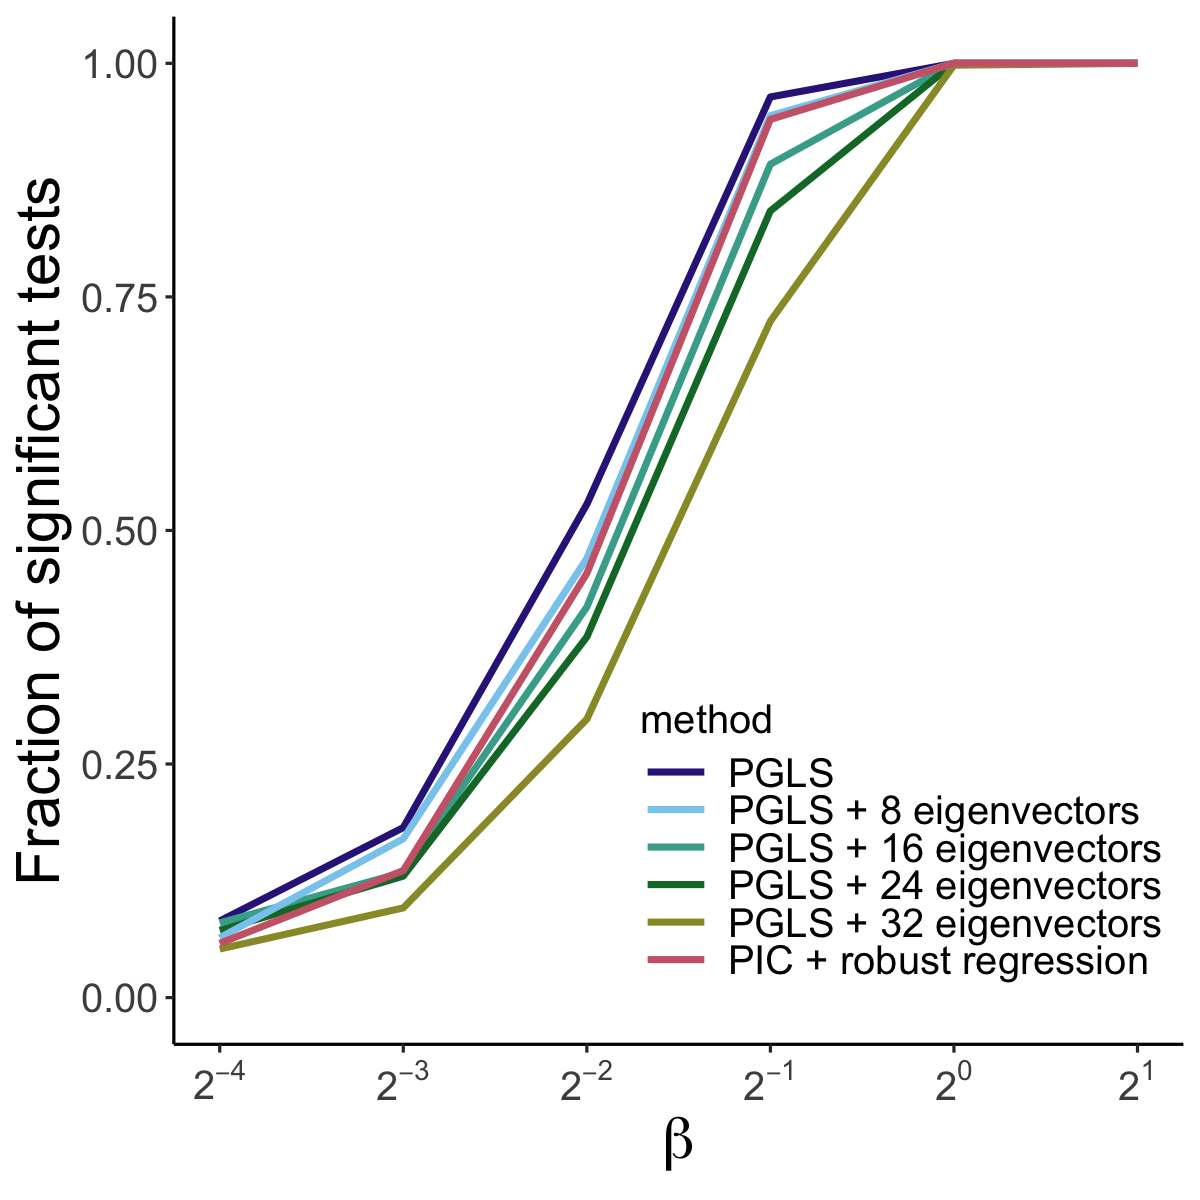

In [153]:
options(repr.plot.width = 10, repr.plot.height = 10)
plot_5

In [154]:
set.seed(19)
yule_tree = sim.bd.taxa(128, 1, 1, 0, 1, complete = FALSE)[[1]]
yule_tree$root.edge=0

PCs = eigen(vcv(yule_tree))$vectors

colnames(PCs) = paste0("PC_",1:ncol(PCs))
PCs = as_tibble(PCs)

num_PC = 64
PC_sets = lapply(seq(from = 16, to = num_PC, by = 16),function(i){paste0("PC_",1:i)})
PC_sets = c("1",PC_sets)

n_edges = length(yule_tree$edge) / 2
n_tips = n_edges / 2 + 1

n_rows = n_beta * num_rep * (length(PC_sets) + 1)

In [155]:
p_vals_PC_6 = data.table(
    PCs=numeric(n_rows),
    p.value=numeric(n_rows), 
    beta.size = numeric(n_rows)
)

counter = 1
set.seed(19)

for (j in 1:num_rep) {
    if (j %% 10 == 0) {message("repeat: ", j)}
        
    for (k in 1:n_beta) {
        beta = betas[k]

        BM = fastBM(yule_tree,1,nsim=2)
        X = BM[,1]
        Y = X * beta + BM[,2]
    
        all_data = as.data.frame(bind_cols(tibble(X = X, Y = Y),PCs))
        rownames(all_data) = rownames(BM)

        for (l in 1:length(PC_sets)) {
            cur_formula = as.formula(paste(c("Y ~ X", PC_sets[[l]]),collapse=" + "))
                
            tryCatch({
                cur_lm = phylolm(cur_formula,data=all_data,phy=yule_tree)
                cur_p = summary(cur_lm)$coefficients["X","p.value"]
                          
                p_vals_PC_6[counter, `:=`("PCs" = 16 * (l - 1), "p.value" = cur_p,  
                                          "beta.size" = beta)]
            }, error = function(e) { 
                    
                p_vals_PC_6[counter, `:=`("PCs" = 16 * (l - 1), "p.value" = NA, 
                                          "beta.size" = beta)]
            })

            counter = counter + 1
        }

        pic_X = pic(X, yule_tree)
        pic_Y = pic(Y, yule_tree)
            
        all_data = as.data.frame(tibble(pic_X = pic_X, pic_Y = pic_Y))

        cur_rlm = lmRob(pic_Y ~ pic_X - 1, data = all_data, 
                        control = lmRob.control(mxr = 1e8))
        cur_p = summary(cur_rlm)$coefficients["pic_X", "Pr(>|t|)"]
        p_vals_PC_6[counter, `:=`("PCs" = -1, "p.value" = cur_p, "beta.size" = beta)]

        counter = counter + 1
    } 
}

repeat: 10

repeat: 20

repeat: 30

repeat: 40

repeat: 50

repeat: 60

repeat: 70

repeat: 80

repeat: 90

Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
repeat: 100

repeat: 110

repeat: 120

repeat: 130

Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
repeat: 140

repeat: 150

repeat: 160

repeat: 170

repeat: 180

repeat: 190

repeat: 200

Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
repeat: 210

repeat: 220

repeat: 230

repeat: 240

Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
repeat: 250

repeat: 260

repeat: 270

Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
repeat: 280

repeat: 290

repeat: 300

repeat: 310

repeat: 320

repeat: 330

Warning me

In [156]:
p_vals_PC_6_summary = p_vals_PC_6 %>%
  mutate(method = case_when(
    PCs == -1 ~ "PIC + robust regression",
    PCs == 0 ~ "PGLS",
    PCs == 16 ~ "PGLS + 16 eigenvectors",
    PCs == 32 ~ "PGLS + 32 eigenvectors", 
    PCs == 48 ~ "PGLS + 48 eigenvectors", 
    PCs == 64 ~ "PGLS + 64 eigenvectors" 
  )) %>% 
  group_by(method, beta.size) %>%
  summarise(FPR = mean(p.value<0.05), n = n(), .groups = "drop")

p_vals_PC_6_summary = as.data.table(p_vals_PC_6_summary) 
p_vals_PC_6_summary$method = factor(p_vals_PC_6_summary$method)

In [157]:
plot_6 <- p_vals_PC_6_summary %>% 
    ggplot(aes(beta.size, FPR)) +
    geom_line(aes(color = method), linewidth=2) +
    theme_classic(base_size=20) +
    xlab(expression(beta)) +
    ylab("Fraction of significant tests") + 
    scale_x_continuous(trans = 'log2', breaks = 2^(-4:1), 
                       labels = function(x) parse(text = paste0("2^", log2(x)))) +
    ylim(0, 1) +
    theme(axis.title.x = element_text(size = 36), axis.title.y = element_text(size = 36), 
          axis.text.x = element_text(size = 24), axis.text.y = element_text(size = 24),
          legend.position=c(.72,.2),legend.spacing.y = unit(1,"pt"), 
          legend.key.width = unit(1.5, "cm"), 
          legend.title = element_text(size = 24), legend.text = element_text(size = 24)) +
    scale_color_manual(values=c("#332288","#88CCEE","#44AA99",
                                "#117733","#999933","#CC6677"), 
                      breaks = c("PGLS", "PGLS + 16 eigenvectors", 
                                 "PGLS + 32 eigenvectors", "PGLS + 48 eigenvectors", 
                                 "PGLS + 64 eigenvectors", "PIC + robust regression")) 

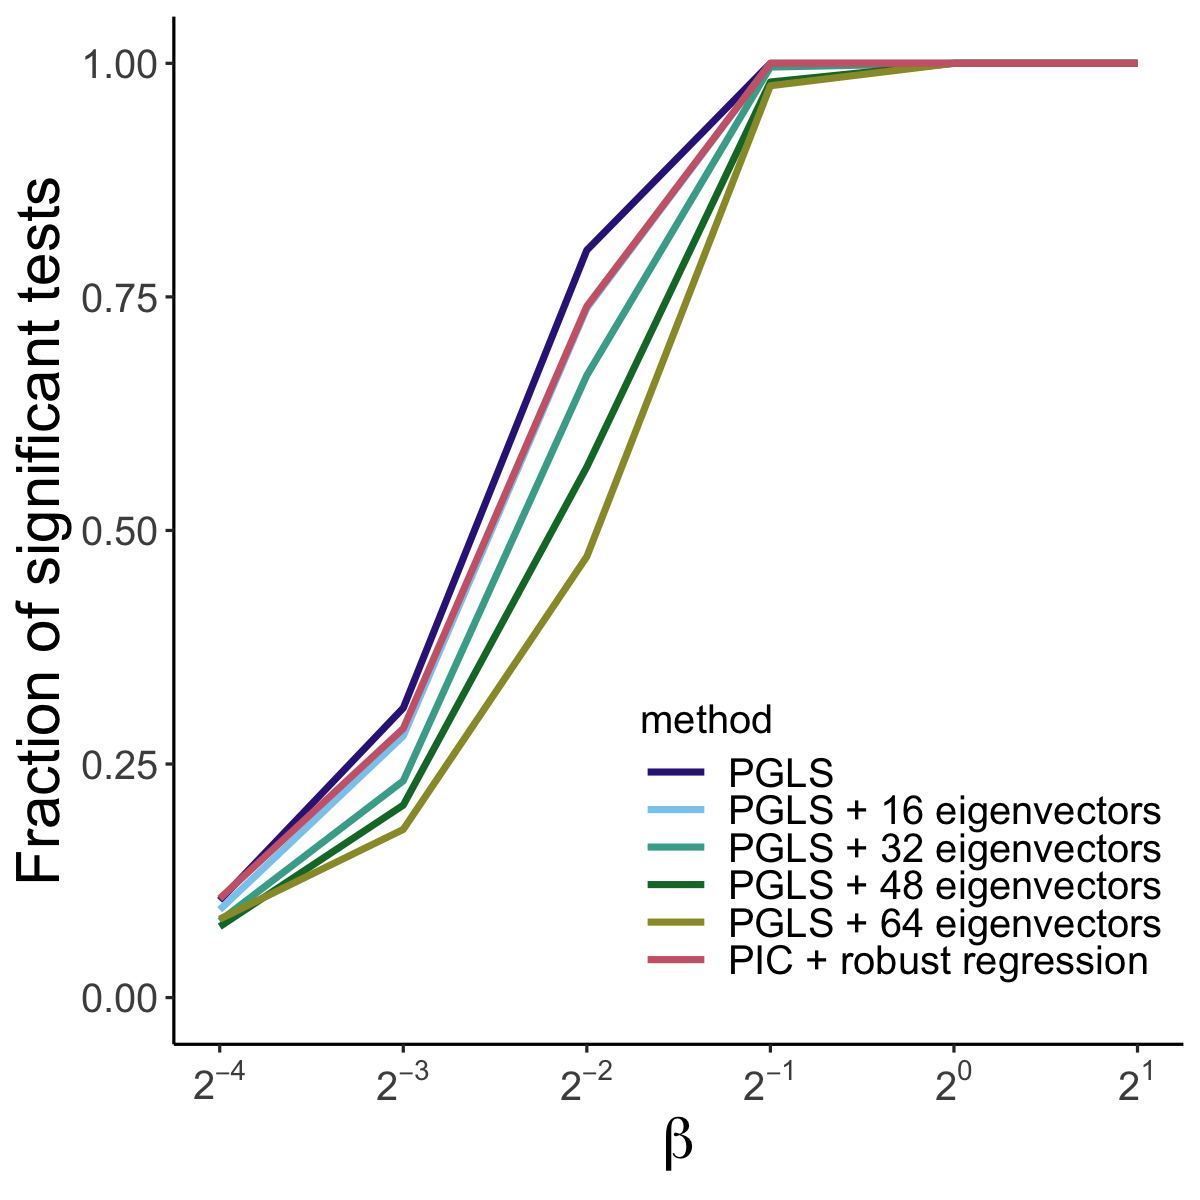

In [158]:
options(repr.plot.width = 10, repr.plot.height = 10)
plot_6

TableGrob (2 x 1) "arrange": 2 grobs
  z     cells    name            grob
1 1 (1-1,1-1) arrange gtable[arrange]
2 2 (2-2,1-1) arrange gtable[arrange]

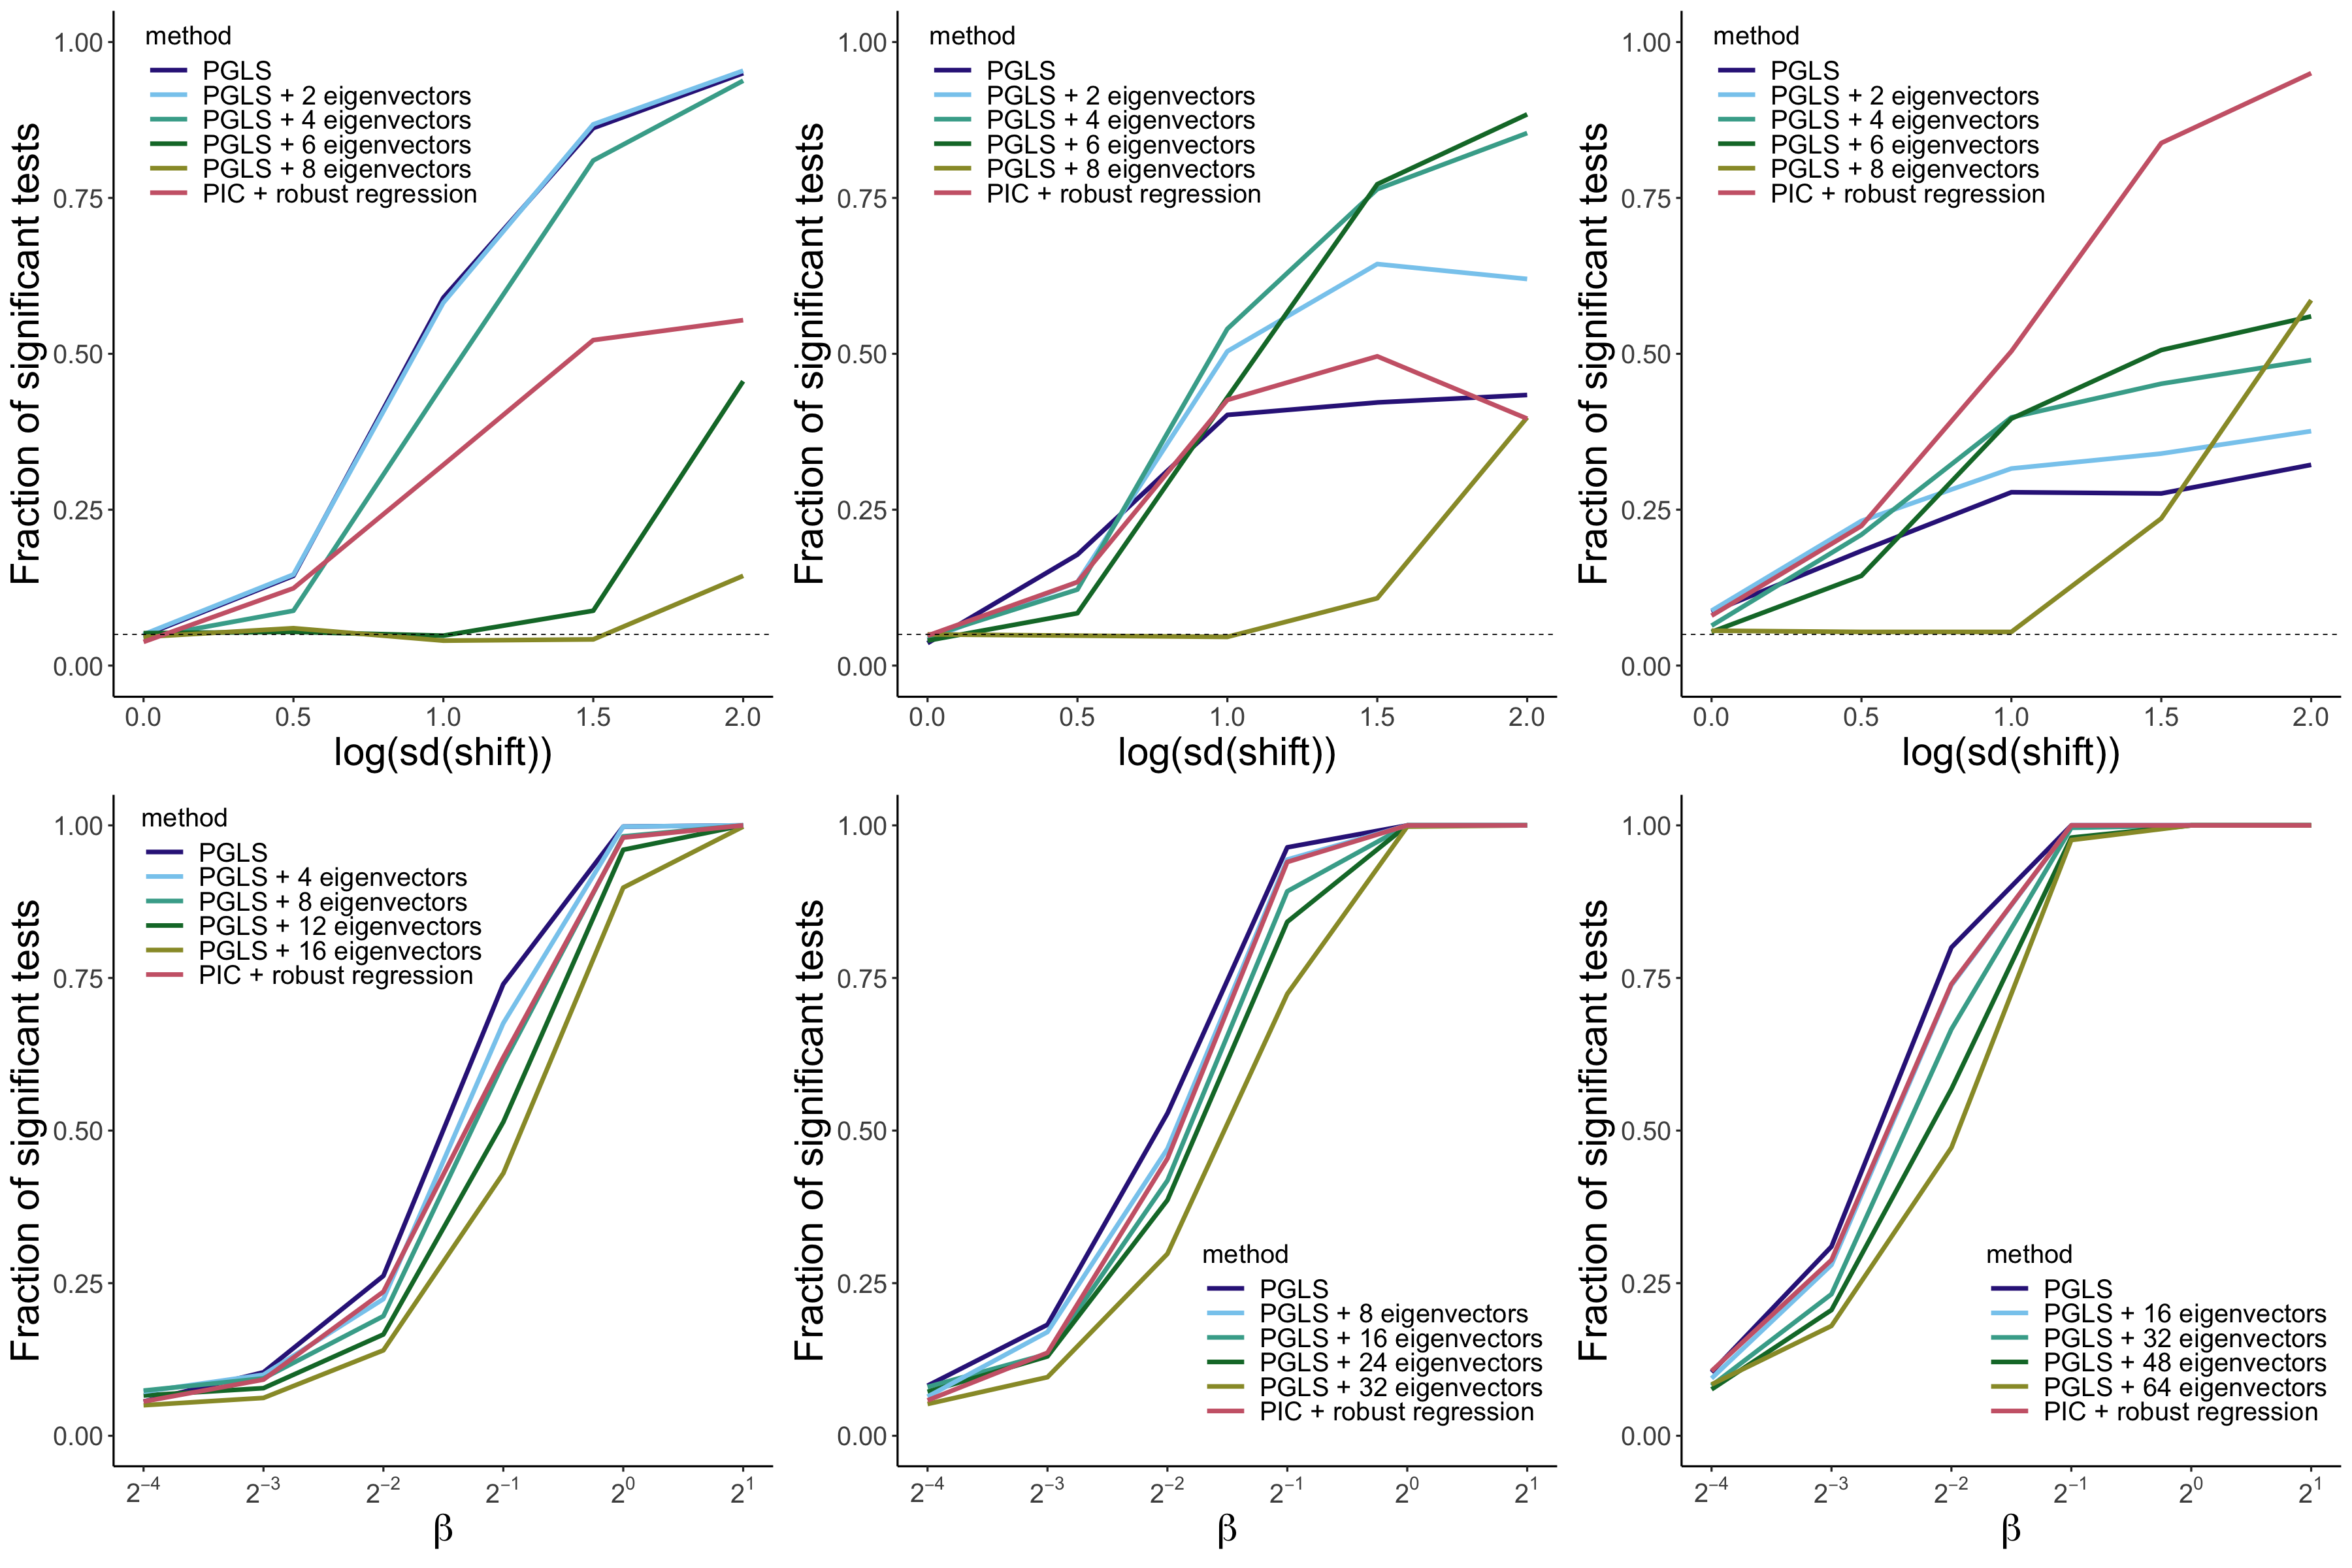

In [161]:
options(repr.plot.width = 30, repr.plot.height = 20)

row1 <- arrangeGrob(plot_1, plot_2, plot_3, ncol = 3)
row2 <- arrangeGrob(plot_4, plot_5, plot_6, ncol = 3)

# Arrange all rows into one layout
g <- grid.arrange(row1, row2, nrow = 2)
g
ggsave("Figures_raw/Figure_6_raw.pdf", g, width = 30, height = 20)
ggsave("Figures_raw/Figure_6_raw.svg", g, width = 30, height = 20)

### 3. Extra work

In [256]:
set.seed(19)
yule_tree = sim.bd.taxa(16, 1, 1, 0, 1, complete = FALSE)[[1]]
yule_tree$root.edge=0

PCs = eigen(vcv(yule_tree))$vectors

colnames(PCs) = paste0("PC_",1:ncol(PCs))
PCs = as_tibble(PCs)

num_PC = 8
PC_sets = lapply(seq(from = 2, to = num_PC, by = 2),function(i){paste0("PC_",1:i)})
PC_sets = c("1",PC_sets)

shifts = 10^(seq(log10(1e-4),log10(1e4), len=10))

betas = 2 ** c(-4:1)

num_TP = 500
num_TN = 500
n_edges = length(yule_tree$edge) / 2
probs = yule_tree$edge.length / sum(yule_tree$edge.length)
n_tips = n_edges / 2 + 1

n_rows = (num_TP + num_TN) * (length(PC_sets) + 1)

In [257]:
p_vals_PC_7 = data.table(
    PCs=numeric(n_rows),
    p.value=numeric(n_rows),  
    shifts=numeric(n_rows),
    betas=numeric(n_rows),
    label=numeric(n_rows)
)

descendants_tips_list <- vector("list", n_edges)
for (j in 1:n_edges) {
    e_cand = yule_tree$edge[j,]
    descendants_cand = getDescendants(yule_tree, e_cand[2])
    descendants_tips_list[[j]] = descendants_cand[descendants_cand <= n_tips]
}

In [258]:
counter = 1
set.seed(19)

for (m in 1:num_TN) {
    if (m %% 20 == 0) {
        message("Testing for TN: ", m)
    }
    BM = fastBM(yule_tree, 1, nsim=2)
    X = BM[,1]
    Y = BM[,2]
    j = sample(1:n_edges, size = 1, prob = probs)
    i = sample(1:length(shifts), size = 1)
    shift = shifts[i]
    descendants_tips = descendants_tips_list[[j]]
    X[descendants_tips] = X[descendants_tips] + rnorm(1,0,sd=sqrt(shift))
    Y[descendants_tips] = Y[descendants_tips] + rnorm(1,0,sd=sqrt(shift))
      
    all_data = as.data.frame(bind_cols(tibble(X = X, Y = Y),PCs))
    rownames(all_data) = rownames(BM)

    for (l in 1:length(PC_sets)) {
        cur_formula = as.formula(paste(c("Y ~ X", PC_sets[[l]]),collapse=" + "))
        tryCatch({
            cur_lm = phylolm(cur_formula,data=all_data,phy=yule_tree)
            cur_p = summary(cur_lm)$coefficients["X","p.value"]                    
            p_vals_PC_7[counter, `:=`("PCs" = 2 * (l - 1), "p.value" = cur_p,
                                      "shifts" = shift, "betas" = 0, "label" = 0)]
        }, error = function(e) {
            p_vals_PC_7[counter, `:=`("PCs" = 2 * (l - 1), "p.value" = NA,
                                      "shifts" = shift, "betas" = 0, "label" = 0)]
        })
        counter = counter + 1
    }

    pic_X = pic(X, yule_tree)
    pic_Y = pic(Y, yule_tree)
            
    all_data = as.data.frame(tibble(pic_X = pic_X, pic_Y = pic_Y))

    cur_rlm = lmRob(pic_Y ~ pic_X - 1, data = all_data, 
                    control = lmRob.control(mxr = 1e8))
    cur_p = summary(cur_rlm)$coefficients["pic_X", "Pr(>|t|)"]
    p_vals_PC_7[counter, `:=`("PCs" = -1, "p.value" = cur_p, "shifts" = shift, 
                              "betas" = 0, "label" = 0)]

    counter = counter + 1 
}

for (m in 1:num_TP) {
    if (m %% 20 == 0) {
        message("Testing for TP: ", m)
    }
    BM = fastBM(yule_tree, 1, nsim=2)
    beta = sample(betas, size = 1)
    X = BM[,1]
    Y = X * beta + BM[,2]
      
    all_data = as.data.frame(bind_cols(tibble(X = X, Y = Y),PCs))
    rownames(all_data) = rownames(BM)

    for (l in 1:length(PC_sets)) {
        cur_formula = as.formula(paste(c("Y ~ X", PC_sets[[l]]),collapse=" + "))
        tryCatch({
            cur_lm = phylolm(cur_formula,data=all_data,phy=yule_tree)
            cur_p = summary(cur_lm)$coefficients["X","p.value"]                    
            p_vals_PC_7[counter, `:=`("PCs" = 2 * (l - 1), "p.value" = cur_p,
                                      "shifts" = 0, "betas" = beta, "label" = 1)]
        }, error = function(e) {
            p_vals_PC_7[counter, `:=`("PCs" = 2 * (l - 1), "p.value" = NA,
                                      "shifts" = 0, "betas" = beta, "label" = 1)]
        })
        counter = counter + 1
    }

    pic_X = pic(X, yule_tree)
    pic_Y = pic(Y, yule_tree)
            
    all_data = as.data.frame(tibble(pic_X = pic_X, pic_Y = pic_Y))

    cur_rlm = lmRob(pic_Y ~ pic_X - 1, data = all_data, 
                    control = lmRob.control(mxr = 1e8))
    cur_p = summary(cur_rlm)$coefficients["pic_X", "Pr(>|t|)"]
    p_vals_PC_7[counter, `:=`("PCs" = -1, "p.value" = cur_p, "shifts" = 0, 
                              "betas" = beta, "label" = 1)]

    counter = counter + 1 
}

Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Testing for TN: 20

Testing for TN: 40

Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Testing for TN: 60

Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Testing for TN: 80

Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Testing for TN: 100

Testing for TN: 120

Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Testing for TN: 140

Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Te

In [259]:
p_vals_PC_7_summary = p_vals_PC_7 %>%
  mutate(method = case_when(
    PCs == -1 ~ "PIC + robust regression",
    PCs == 0 ~ "PGLS",
    PCs == 2 ~ "PGLS + 2 eigenvectors",
    PCs == 4 ~ "PGLS + 4 eigenvectors", 
    PCs == 6 ~ "PGLS + 6 eigenvectors", 
    PCs == 8 ~ "PGLS + 8 eigenvectors" 
  ))

p_vals_PC_7_summary = as.data.table(p_vals_PC_7_summary) 
p_vals_PC_7_summary$method = factor(p_vals_PC_7_summary$method)

In [209]:
install.packages("pROC")
library(pROC)


The downloaded binary packages are in
	/var/folders/gh/wjs3pzl11758g8crdf96rf8c0000gn/T//Rtmp3lKtuH/downloaded_packages


In [260]:
p_vals_PC_7_summary$score <- -log10(p_vals_PC_7_summary$p.value)

In [261]:
roc_list <- p_vals_PC_7_summary %>%
  mutate(score = -log10(p.value)) %>%
  group_by(method) %>%
  group_map(~ {
    roc_obj <- roc(.x$label, .x$score, quiet = TRUE)
    
    data.frame(
      method = .y$method,
      TPR = roc_obj$sensitivities,
      FPR = 1 - roc_obj$specificities
    )
  })

roc_df <- bind_rows(roc_list)

In [262]:
plot_7 <- roc_df %>% 
    ggplot(aes(FPR, TPR)) +
    geom_line(aes(color = method), linewidth=2) +
    theme_classic(base_size=20) +
    xlab("False positive rate") +
    ylab("True positive rate") + 
    xlim(0, 1) +
    ylim(0, 1) +
    geom_abline(slope = 1, intercept = 0,lty = 2) +
    theme(axis.title.x = element_text(size = 36), axis.title.y = element_text(size = 36), 
          axis.text.x = element_text(size = 24), axis.text.y = element_text(size = 24),
          legend.position=c(.7,.2),legend.spacing.y = unit(1,"pt"), 
          legend.key.width = unit(1.5, "cm"), 
          legend.title = element_text(size = 24), legend.text = element_text(size = 24)) +
    scale_color_manual(values=c("#332288","#88CCEE","#44AA99",
                                "#117733","#999933","#CC6677"), 
                      breaks = c("PGLS", "PGLS + 2 eigenvectors", 
                                 "PGLS + 4 eigenvectors", "PGLS + 6 eigenvectors", 
                                 "PGLS + 8 eigenvectors", "PIC + robust regression")) 

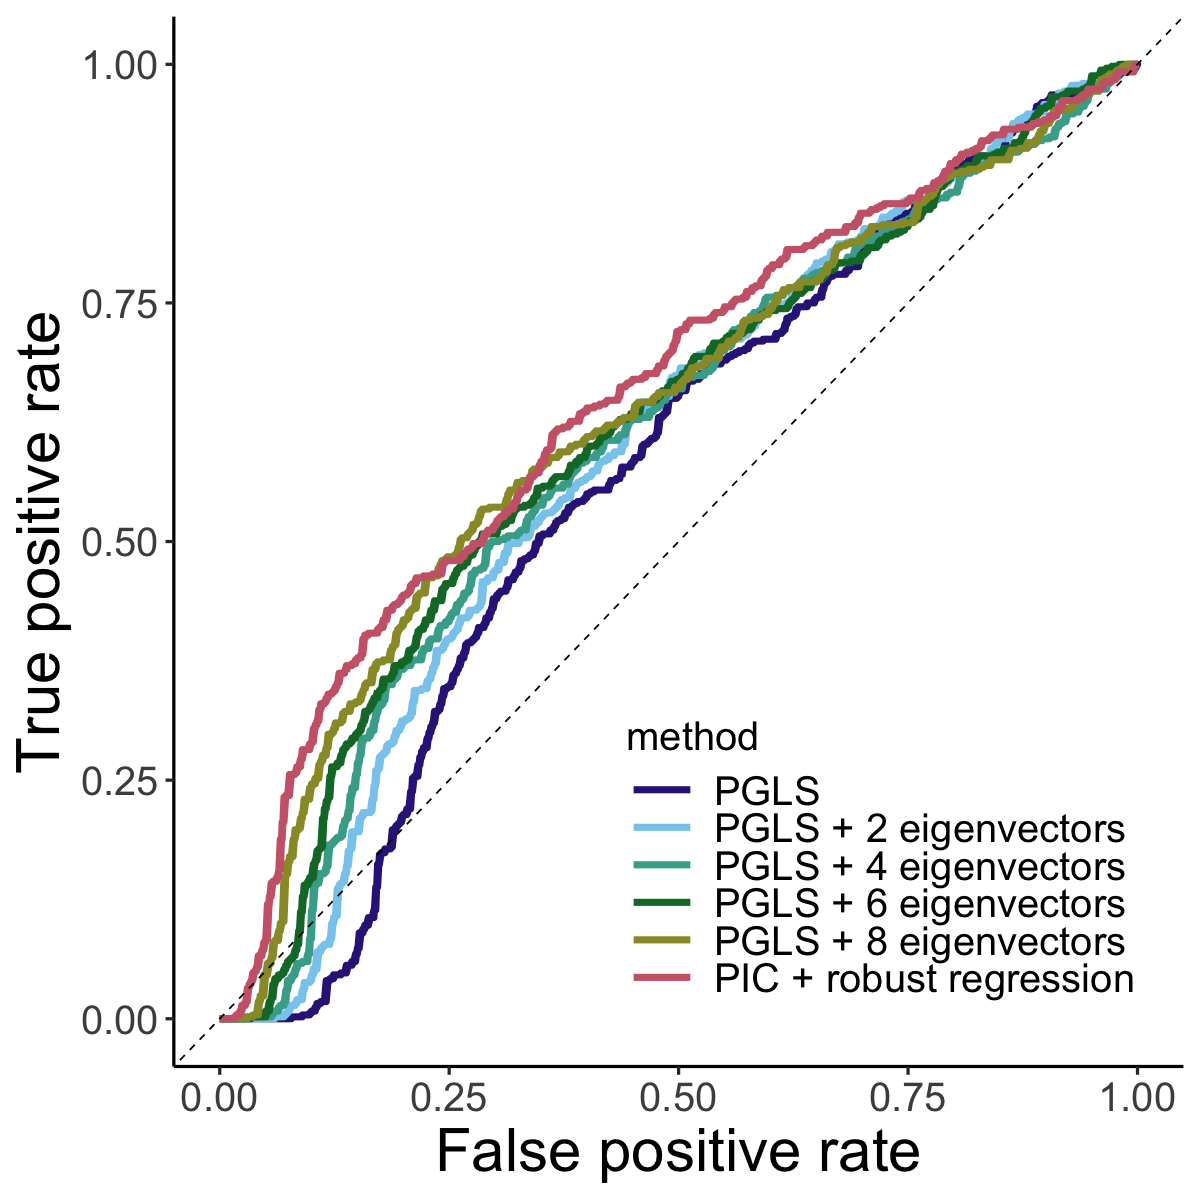

In [263]:
options(repr.plot.width = 10, repr.plot.height = 10)
plot_7